In [1]:
import glob
import numpy as np, pandas as pd

hits = glob.glob("/kaggle/input/**/price_panel.csv", recursive=True)
assert hits, "price_panel.csv not found. Add the output of food-01-data-check as an input."
panel = pd.read_csv(hits[0], parse_dates=["month"])

prices = panel.pivot(index="month", columns="series", values="price")   
observed = panel.pivot(index="month", columns="series", values="observed").fillna(False).astype(bool)
print("Months:", prices.index.min().date(), "to", prices.index.max().date(), "|", prices.shape[0], "months x", prices.shape[1], "series")
print("\nEmpty cells per series (Yobe ends a month earlier):"); print(prices.isna().sum().to_string())

Months: 2017-02-01 to 2026-09-01 | 116 months x 10 series

Empty cells per series (Yobe ends a month earlier):
series
Borno | Millet             0
Borno | Oil (palm)         0
Borno | Rice (imported)    0
Borno | Rice (local)       0
Borno | Yam                0
Yobe | Millet              1
Yobe | Oil (palm)          1
Yobe | Rice (imported)     1
Yobe | Rice (local)        1
Yobe | Yam                 1


/tmp/ipykernel_16/4118853575.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  observed = panel.pivot(index="month", columns="series", values="observed").fillna(False).astype(bool)


In [2]:
logp = np.log(prices)
HORIZONS = [1, 3, 6]                               
FIRST_ORIGIN = pd.Timestamp("2021-01-01")   

baselines = {
    "Last value":            lambda hist, h: hist.iloc[-1],
    "Same month last year":  lambda hist, h: hist.iloc[h - 13],
    "Average of last 3":     lambda hist, h: hist.iloc[-3:].mean(),
    "Last value + trend":    lambda hist, h: hist.iloc[-1] + h * (hist.iloc[-1] - hist.iloc[-13]) / 12,
}

rows = []
for s in logp.columns:
    series = logp[s].dropna()
    for origin in series.index[series.index >= FIRST_ORIGIN]:
        hist = series.loc[:origin]                          
        for h in HORIZONS:
            target = origin + pd.DateOffset(months=h)
            if target not in series.index or not observed.loc[target, s]:
                continue                                       
            actual = np.exp(series[target])
            for name, method in baselines.items():
                forecast = np.exp(method(hist, h))
                rows.append({"series": s, "origin": origin, "target": target, "h": h, "method": name,
                             "error_pct": (forecast - actual) / actual * 100})
bl = pd.DataFrame(rows)
bl["period"] = pd.cut(bl.target, [pd.Timestamp("2000-01-01"), pd.Timestamp("2023-06-01"), pd.Timestamp("2024-07-01"), pd.Timestamp("2030-01-01")],
                      right=False, labels=["before shock", "shock year", "after"])
print("Forecasts scored:", len(bl), "| per method and horizon:", len(bl) // (len(baselines) * len(HORIZONS)), "on average")

print("\nAverage size of the error (%), by how far ahead:")
print(bl.assign(abs_err=bl.error_pct.abs()).pivot_table(index="method", columns="h", values="abs_err", aggfunc="mean").round(1).to_string())

print("\n3 months ahead: average size of the error (%), by period:")
three = bl[bl.h == 3].assign(abs_err=lambda d: d.error_pct.abs())
print(three.pivot_table(index="method", columns="period", values="abs_err", aggfunc="mean", observed=True).round(1).to_string())
print("\n3 months ahead: average direction of the error (%; positive = forecast too high):")
print(three.pivot_table(index="method", columns="period", values="error_pct", aggfunc="mean", observed=True).round(1).to_string())
bl.to_csv("/kaggle/working/baseline_forecasts.csv", index=False)

Forecasts scored: 7700 | per method and horizon: 641 on average

Average size of the error (%), by how far ahead:
h                        1     3     6
method                                
Average of last 3     10.2  16.6  23.5
Last value             7.4  14.7  22.1
Last value + trend     7.9  16.7  28.7
Same month last year  30.4  30.4  30.7

3 months ahead: average size of the error (%), by period:
period                before shock  shock year  after
method                                               
Average of last 3             15.4        20.9   15.8
Last value                    13.9        18.2   13.8
Last value + trend            15.7        15.9   18.0
Same month last year          20.9        41.2   34.6

3 months ahead: average direction of the error (%; positive = forecast too high):
period                before shock  shock year  after
method                                               
Average of last 3             -4.3       -18.3    2.1
Last value              

In [3]:
import warnings
from statsmodels.tsa.holtwinters import ExponentialSmoothing
warnings.filterwarnings("ignore")           

def ets_forecast(hist, seasonal):
    """Fit exponential smoothing to the log prices up to the origin; return forecasts for 1 to 6 months ahead."""
    model = ExponentialSmoothing(hist.values, trend="add", damped_trend=True,
                                 seasonal="add" if seasonal else None, seasonal_periods=12 if seasonal else None,
                                 initialization_method="estimated")
    return model.fit().forecast(max(HORIZONS))

def backtest(forecaster):
    """Stand at every month from 2021, forecast with only the past, and score against real prices."""
    rows = []
    for s in logp.columns:
        series = logp[s].dropna()
        for origin in series.index[series.index >= FIRST_ORIGIN]:
            path = forecaster(series.loc[:origin])
            for h in HORIZONS:
                target = origin + pd.DateOffset(months=h)
                if target not in series.index or not observed.loc[target, s]:
                    continue
                actual = np.exp(series[target])
                rows.append({"series": s, "origin": origin, "target": target, "h": h,
                             "error_pct": (np.exp(path[h - 1]) - actual) / actual * 100})
    return pd.DataFrame(rows)

test = logp["Borno | Millet"].dropna().loc[:"2023-05-01"]
print("Borno millet, standing at May 2023. Last price:", round(np.exp(test.iloc[-1])))
print("ETS forecasts for June to November 2023:", np.exp(ets_forecast(test, seasonal=True)).round(0))

Borno millet, standing at May 2023. Last price: 832
ETS forecasts for June to November 2023: [837. 802. 923. 815. 770. 788.]


In [4]:
import time

def label_periods(df):
    edges = [pd.Timestamp("2000-01-01"), pd.Timestamp("2023-06-01"), pd.Timestamp("2024-07-01"), pd.Timestamp("2030-01-01")]
    return df.assign(period=pd.cut(df.target, edges, right=False, labels=["before shock", "shock year", "after"]))

def report(df):
    df = df.assign(abs_err=df.error_pct.abs())
    print("Average size of the error (%), by how far ahead:")
    print(df.pivot_table(index="method", columns="h", values="abs_err", aggfunc="mean").round(1).to_string())
    three = df[df.h == 3]
    print("\n3 months ahead, average size of the error (%), by period:")
    print(three.pivot_table(index="method", columns="period", values="abs_err", aggfunc="mean", observed=True).round(1).to_string())
    print("\n3 months ahead, average direction of the error (%; positive = too high):")
    print(three.pivot_table(index="method", columns="period", values="error_pct", aggfunc="mean", observed=True).round(1).to_string())

results = [bl]
for name, seasonal in [("ETS, damped trend", False), ("ETS, damped trend + season", True)]:
    start = time.time()
    r = backtest(lambda hist, seasonal=seasonal: ets_forecast(hist, seasonal))
    results.append(r.assign(method=name))
    print(f"{name}: {len(r)} forecasts in {time.time() - start:.0f} seconds")

forecasts = label_periods(pd.concat(results, ignore_index=True).drop(columns="period", errors="ignore"))
print()
report(forecasts)
forecasts.to_csv("/kaggle/working/forecasts.csv", index=False)

ETS, damped trend: 1925 forecasts in 21 seconds
ETS, damped trend + season: 1925 forecasts in 100 seconds

Average size of the error (%), by how far ahead:
h                              1     3     6
method                                      
Average of last 3           10.2  16.6  23.5
ETS, damped trend            8.3  15.8  24.0
ETS, damped trend + season   9.6  15.9  23.7
Last value                   7.4  14.7  22.1
Last value + trend           7.9  16.7  28.7
Same month last year        30.4  30.4  30.7

3 months ahead, average size of the error (%), by period:
period                      before shock  shock year  after
method                                                     
Average of last 3                   15.4        20.9   15.8
ETS, damped trend                   15.0        18.2   15.5
ETS, damped trend + season          15.8        16.7   15.6
Last value                          13.9        18.2   13.8
Last value + trend                  15.7        15.9   18.0
Same 

In [5]:
parts = []
diffs = logp.diff()
for s in logp.columns:
    x = logp[s]
    d = pd.DataFrame({"month": logp.index, "series": s})
    d["state"], d["food"] = s.split(" | ")
    for k in [1, 3, 6, 12]:
        d[f"change_{k}m"] = (x - x.shift(k)).values            
    d["jumpiness_6m"] = diffs[s].rolling(6).std().values      
    d["vs_12m_average"] = (x - x.rolling(12).mean()).values         
    d["all_foods_change_1m"] = diffs.mean(axis=1).values     
    d["all_foods_change_3m"] = (logp - logp.shift(3)).mean(axis=1).values
    for h in HORIZONS:
        d[f"target_{h}"] = (x.shift(-h) - x).values              
        d[f"real_{h}"] = observed[s].astype(float).shift(-h).fillna(0).astype(bool).values
        d[f"target_month_{h}"] = d.month + pd.DateOffset(months=h)
    parts.append(d)

feat = pd.concat(parts, ignore_index=True)
feat["calendar_month"] = feat.month.dt.month
feat["state"] = feat.state.astype("category"); feat["food"] = feat.food.astype("category")
FEATURES = ["change_1m", "change_3m", "change_6m", "change_12m", "jumpiness_6m", "vs_12m_average",
            "all_foods_change_1m", "all_foods_change_3m", "calendar_month", "state", "food"]
feat = feat.dropna(subset=["change_12m", "jumpiness_6m", "vs_12m_average"])
print("Rows (one per series and month):", len(feat), "| from", feat.month.min().date(), "to", feat.month.max().date())
print(feat[["series", "month"] + FEATURES[:6] + ["target_3"]].tail(3).round(3).to_string())

Rows (one per series and month): 1035 | from 2018-02-01 to 2026-09-01
          series      month  change_1m  change_3m  change_6m  change_12m  jumpiness_6m  vs_12m_average  target_3
1156  Yobe | Yam 2026-06-01      0.023      0.246      0.245      -0.067         0.086           0.106       NaN
1157  Yobe | Yam 2026-07-01      0.028      0.069      0.272      -0.173         0.084           0.148       NaN
1158  Yobe | Yam 2026-08-01      0.072      0.123      0.300       0.163         0.085           0.207       NaN


In [6]:
import lightgbm as lgb

params = dict(n_estimators=300, learning_rate=0.03, num_leaves=7, min_child_samples=20, subsample=0.8,
              subsample_freq=1, colsample_bytree=0.8, reg_lambda=1.0, random_state=42, verbose=-1)
origins = sorted(feat.month[feat.month >= FIRST_ORIGIN].unique())
rows, latest, start = [], {}, time.time()
for h in HORIZONS:
    for origin in origins:
        train = feat[(feat[f"target_month_{h}"] <= origin) & feat[f"real_{h}"]]    
        now = feat[(feat.month == origin) & feat[f"real_{h}"]]
        if now.empty:
            continue
        model = lgb.LGBMRegressor(**params).fit(train[FEATURES], train[f"target_{h}"])
        latest[h] = model                                                 
        predicted = model.predict(now[FEATURES])
        for s, p, y in zip(now.series, predicted, now[f"target_{h}"]):
            rows.append({"series": s, "origin": origin, "target": origin + pd.DateOffset(months=h), "h": h,
                         "error_pct": (np.exp(p - y) - 1) * 100, "method": "LightGBM (all series together)"})
    print(f"{h} month(s) ahead: done after {time.time() - start:.0f} seconds")

lgbm = pd.DataFrame(rows)
print("Forecasts:", len(lgbm), "| same number as each simple rule:", len(lgbm) == (forecasts.method == "Last value").sum())
forecasts = label_periods(pd.concat([forecasts.drop(columns="period"), lgbm], ignore_index=True))
print()
report(forecasts)
forecasts.to_csv("/kaggle/working/forecasts.csv", index=False)

print("\nWhat the 3-months-ahead model relied on most (latest version):")
importance = pd.Series(latest[3].booster_.feature_importance("gain"), index=FEATURES)
print((importance / importance.sum() * 100).sort_values(ascending=False).round(1).to_string())

1 month(s) ahead: done after 7 seconds
3 month(s) ahead: done after 13 seconds
6 month(s) ahead: done after 19 seconds
Forecasts: 1925 | same number as each simple rule: True

Average size of the error (%), by how far ahead:
h                                  1     3     6
method                                          
Average of last 3               10.2  16.6  23.5
ETS, damped trend                8.3  15.8  24.0
ETS, damped trend + season       9.6  15.9  23.7
Last value                       7.4  14.7  22.1
Last value + trend               7.9  16.7  28.7
LightGBM (all series together)   9.4  16.8  24.6
Same month last year            30.4  30.4  30.7

3 months ahead, average size of the error (%), by period:
period                          before shock  shock year  after
method                                                         
Average of last 3                       15.4        20.9   15.8
ETS, damped trend                       15.0        18.2   15.5
ETS, damped trend +

In [7]:
rng = np.random.default_rng(42)
B, BLOCK = 2000, 6                  
months = np.array(sorted(forecasts.origin.unique()))

def block_sample():
    """Pick whole 6-month stretches at random, because neighbouring months' errors are linked."""
    starts = rng.integers(0, len(months) - BLOCK + 1, size=int(np.ceil(len(months) / BLOCK)))
    return np.concatenate([np.arange(s, s + BLOCK) for s in starts])[:len(months)]

samples = [block_sample() for _ in range(B)]
key = ["series", "origin", "h"]
base = forecasts[forecasts.method == "Last value"].set_index(key).error_pct.abs()

rows = []
for method in forecasts.method.unique():
    if method == "Last value":
        continue
    m = forecasts[forecasts.method == method].set_index(key).error_pct.abs()
    diff = (m - base.reindex(m.index)).reset_index(name="diff")          
    for h in HORIZONS:
        per_month = diff[diff.h == h].groupby("origin")["diff"].agg(["sum", "count"]).reindex(months, fill_value=0)
        s, c = per_month["sum"].to_numpy(), per_month["count"].to_numpy()
        boot = [s[i].sum() / c[i].sum() for i in samples]
        rows.append({"method": method, "h": h, "difference": s.sum() / c.sum(),
                     "ci_low": np.quantile(boot, 0.025), "ci_high": np.quantile(boot, 0.975)})

vs_last = pd.DataFrame(rows).round(1)
print("Error compared with 'last value', in percentage points (positive = worse), with 95% confidence intervals:")
vs_last["result"] = vs_last.apply(lambda r: f"{r.difference:+.1f}  ({r.ci_low:+.1f} to {r.ci_high:+.1f})", axis=1)
print(vs_last.pivot(index="method", columns="h", values="result").to_string())
vs_last.to_csv("/kaggle/working/vs_last_value.csv", index=False)

Error compared with 'last value', in percentage points (positive = worse), with 95% confidence intervals:
h                                                     1                        3                      6
method                                                                                                 
Average of last 3                  +2.8  (+2.1 to +3.9)     +1.9  (+1.2 to +2.8)   +1.3  (+0.4 to +2.2)
ETS, damped trend                  +0.9  (+0.6 to +1.3)     +1.1  (+0.4 to +1.8)   +1.9  (+0.3 to +3.7)
ETS, damped trend + season         +2.2  (+1.5 to +2.9)     +1.2  (-0.3 to +2.8)   +1.5  (-0.7 to +4.5)
Last value + trend                 +0.5  (+0.0 to +1.0)     +2.0  (-0.2 to +4.5)  +6.6  (+0.3 to +14.0)
LightGBM (all series together)     +2.0  (+1.4 to +2.7)     +2.1  (+0.6 to +3.3)   +2.5  (-0.4 to +4.9)
Same month last year            +23.0  (+17.6 to +28.9)  +15.7  (+10.0 to +21.6)  +8.6  (+3.3 to +13.4)


In [8]:
keep = ["Last value", "Last value + trend", "ETS, damped trend + season", "LightGBM (all series together)"]
three = forecasts[(forecasts.h == 3) & forecasts.method.isin(keep)].assign(abs_err=lambda d: d.error_pct.abs(),
                                                                           food=lambda d: d.series.str.split(" | ", regex=False).str[1])
print("3 months ahead, average size of the error (%), by food (both states):")
print(three.pivot_table(index="food", columns="method", values="abs_err", aggfunc="mean")[keep].round(1).to_string())

wins = (three.pivot_table(index=["series", "origin"], columns="method", values="abs_err")[keep]
        .apply(lambda r: r.idxmin(), axis=1).value_counts(normalize=True) * 100)
print("\nShare of individual forecasts where each method was the closest (%):")
print(wins.round(1).to_string())

3 months ahead, average size of the error (%), by food (both states):
method           Last value  Last value + trend  ETS, damped trend + season  LightGBM (all series together)
food                                                                                                       
Millet                 17.4                18.1                        17.9                            21.5
Oil (palm)              9.6                11.1                        10.5                            10.5
Rice (imported)        13.6                15.3                        14.7                            15.2
Rice (local)           11.7                12.4                        13.4                            12.4
Yam                    21.1                26.6                        22.9                            24.5

Share of individual forecasts where each method was the closest (%):
Last value + trend                28.7
LightGBM (all series together)    24.7
Last value                

In [9]:
LOW, HIGH = 0.10, 0.90                            
food_of = {s: s.split(" | ")[1] for s in logp.columns}
origins = [m for m in logp.index if m >= FIRST_ORIGIN]

rows = []
for h in HORIZONS:
    real_target = observed.astype(float).shift(-h).fillna(0).astype(bool)
    change = (logp.shift(-h) - logp).where(real_target)     
    for origin in origins:
        known = change.loc[: origin - pd.DateOffset(months=h)]    
        recent = known.loc[origin - pd.DateOffset(months=h + 23):]  
        for s in logp.columns:
            if pd.isna(change.loc[origin, s]):
                continue                             
            same_food = [c for c in logp.columns if food_of[c] == food_of[s]]
            actual = change.loc[origin, s]
            for name, pool in [("All past changes", known), ("Last 24 months only", recent)]:
                lo, hi = np.quantile(pool[same_food].stack().dropna(), [LOW, HIGH])
                rows.append({"series": s, "origin": origin, "target": origin + pd.DateOffset(months=h), "h": h, "method": name,
                             "inside": lo <= actual <= hi, "above": actual > hi, "below": actual < lo,
                             "width_pct": (np.exp(hi) - np.exp(lo)) * 100})
ranges = label_periods(pd.DataFrame(rows))

summary = ranges.groupby(["method", "h", "period"], observed=True).agg(
    inside=("inside", "mean"), above=("above", "mean"), below=("below", "mean"), width=("width_pct", "mean"))
summary[["inside", "above", "below"]] *= 100
print("80% ranges around 'last value': share of real prices inside (should be about 80%), above, below, and average width (%):")
print(summary.round(1).to_string())
ranges.to_csv("/kaggle/working/prediction_ranges.csv", index=False)

80% ranges around 'last value': share of real prices inside (should be about 80%), above, below, and average width (%):
                                    inside  above  below  width
method              h period                                   
All past changes    1 before shock    83.9   10.0    6.1   24.3
                      shock year      71.2   20.0    8.8   24.0
                      after           77.7    7.7   14.6   24.5
                    3 before shock    81.2   12.7    6.2   45.6
                      shock year      70.4   25.6    4.0   48.3
                      after           76.2    6.9   16.9   50.6
                    6 before shock    80.4   13.9    5.7   63.5
                      shock year      59.2   36.0    4.8   69.3
                      after           67.3    7.3   25.4   81.1
Last 24 months only 1 before shock    77.5   11.8   10.7   18.3
                      shock year      62.4   24.0   13.6   21.0
                      after           74.6    9.

In [10]:
three = ranges[ranges.h == 3].assign(half_year=lambda d: d.target.dt.year.astype(str) + np.where(d.target.dt.month <= 6, " Jan-Jun", " Jul-Dec"))
over_time = three.pivot_table(index="half_year", columns="method", values="inside", aggfunc="mean") * 100
over_time["forecasts"] = three.groupby("half_year").size() // 2
print("3 months ahead: share of real prices inside the 80% range, by half-year (%):")
print(over_time.round(0).to_string())

3 months ahead: share of real prices inside the 80% range, by half-year (%):
method        All past changes  Last 24 months only  forecasts
half_year                                                     
2021 Jan-Jun              90.0                 87.0         30
2021 Jul-Dec              93.0                 90.0         60
2022 Jan-Jun              85.0                 77.0         60
2022 Jul-Dec              72.0                 62.0         60
2023 Jan-Jun              68.0                 62.0         60
2023 Jul-Dec              71.0                 69.0         55
2024 Jan-Jun              70.0                 72.0         60
2024 Jul-Dec              76.0                 65.0         55
2025 Jan-Jun              83.0                 52.0         60
2025 Jul-Dec              57.0                 53.0         60
2026 Jan-Jun              83.0                 75.0         60
2026 Jul-Dec              88.0                 92.0         25


In [11]:
rows = []
for s in logp.columns:
    series = logp[s].dropna()
    last_month, last_log = series.index[-1], series.iloc[-1]
    same_food = [c for c in logp.columns if food_of[c] == food_of[s]]
    for h in range(1, 7):
        real_target = observed.astype(float).shift(-h).fillna(0).astype(bool)
        past = (logp.shift(-h) - logp).where(real_target)[same_food].stack().dropna()   
        lo, hi = np.quantile(past, [LOW, HIGH])
        rows.append({"series": s, "from": last_month, "month": last_month + pd.DateOffset(months=h), "h": h,
                     "forecast": np.exp(last_log), "low_80": np.exp(last_log + lo), "high_80": np.exp(last_log + hi)})
outlook = pd.DataFrame(rows)
outlook.to_csv("/kaggle/working/price_outlook.csv", index=False)

show = outlook[outlook.h.isin([1, 3, 6])].copy()
show["text"] = show.apply(lambda r: f"₦{r.forecast:,.0f}  (₦{r.low_80:,.0f} to ₦{r.high_80:,.0f})", axis=1)
show["when"] = show.month.dt.strftime("%b %Y")
print("Price outlook: best single forecast (today's price) and 80% range (naira, in each food's own unit)\n")
for s, g in show.groupby("series"):
    print(f"{s} (last price {g['from'].iloc[0]:%b %Y}):")
    for _, r in g.iterrows():
        print(f"   {r.when}: {r.text}")

Price outlook: best single forecast (today's price) and 80% range (naira, in each food's own unit)

Borno | Millet (last price Sep 2026):
   Oct 2026: ₦1,050  (₦911 to ₦1,226)
   Dec 2026: ₦1,050  (₦823 to ₦1,399)
   Mar 2027: ₦1,050  (₦740 to ₦1,715)
Borno | Oil (palm) (last price Sep 2026):
   Oct 2026: ₦2,850  (₦2,647 to ₦3,163)
   Dec 2026: ₦2,850  (₦2,517 to ₦3,475)
   Mar 2027: ₦2,850  (₦2,502 to ₦3,681)
Borno | Rice (imported) (last price Sep 2026):
   Oct 2026: ₦4,000  (₦3,758 to ₦4,387)
   Dec 2026: ₦4,000  (₦3,369 to ₦5,090)
   Mar 2027: ₦4,000  (₦3,198 to ₦5,874)
Borno | Rice (local) (last price Sep 2026):
   Oct 2026: ₦3,250  (₦3,010 to ₦3,605)
   Dec 2026: ₦3,250  (₦2,758 to ₦4,131)
   Mar 2027: ₦3,250  (₦2,572 to ₦4,896)
Borno | Yam (last price Sep 2026):
   Oct 2026: ₦3,250  (₦2,799 to ₦3,983)
   Dec 2026: ₦3,250  (₦2,602 to ₦5,046)
   Mar 2027: ₦3,250  (₦2,413 to ₦6,503)
Yobe | Millet (last price Aug 2026):
   Sep 2026: ₦1,046  (₦908 to ₦1,222)
   Nov 2026: ₦1,046  (₦82

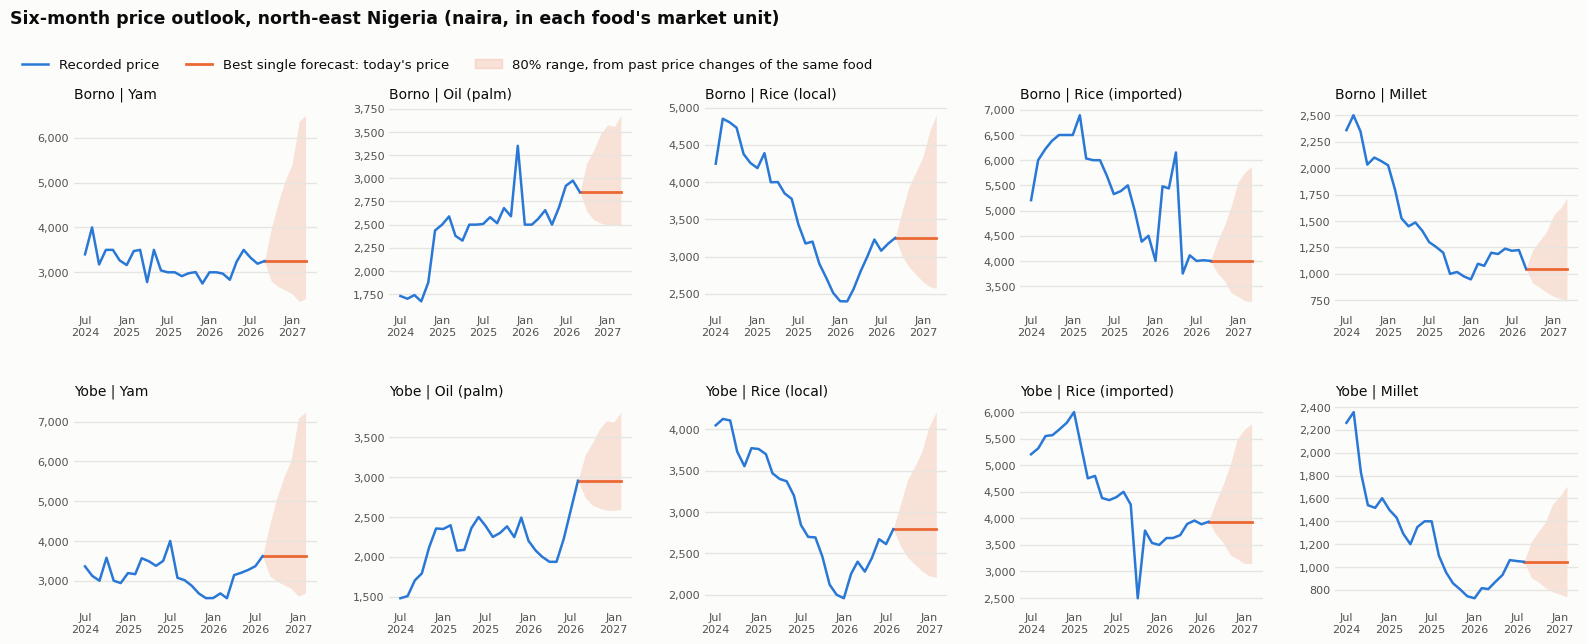

In [12]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter

BLUE, ORANGE, INK, MUTED, GRID, SURFACE = "#2a78d6", "#eb6834", "#0b0b0b", "#52514e", "#e6e5e0", "#fcfcfb"
fig, axes = plt.subplots(2, 5, figsize=(16, 6.6), dpi=100)
fig.patch.set_facecolor(SURFACE)
for i, state in enumerate(["Borno", "Yobe"]):
    for j, food in enumerate(["Yam", "Oil (palm)", "Rice (local)", "Rice (imported)", "Millet"]):
        s = f"{state} | {food}"
        ax, hist, out = axes[i, j], prices[s].dropna().loc["2024-07-01":], outlook[outlook.series == s]
        start = pd.DataFrame({"month": [hist.index[-1]], "forecast": [hist.iloc[-1]], "low_80": [hist.iloc[-1]], "high_80": [hist.iloc[-1]]})
        out = pd.concat([start, out], ignore_index=True)                  
        ax.set_facecolor(SURFACE)
        ax.fill_between(out.month, out.low_80, out.high_80, color=ORANGE, alpha=0.18, lw=0)
        ax.plot(out.month, out.forecast, color=ORANGE, lw=2)
        ax.plot(hist.index, hist.values, color=BLUE, lw=1.8)
        ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:,.0f}"))
        ax.set_title(s, fontsize=10, color=INK, loc="left")
        ax.grid(axis="y", color=GRID, lw=1); ax.tick_params(colors=MUTED, labelsize=8, length=0)
        ax.tick_params(axis="x", rotation=0); ax.xaxis.set_major_locator(plt.matplotlib.dates.MonthLocator(bymonth=[1, 7]))
        ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%b\n%Y"))
        for sp in ax.spines.values():
            sp.set_visible(False)

handles = [Line2D([], [], color=BLUE, lw=1.8, label="Recorded price"),
           Line2D([], [], color=ORANGE, lw=2, label="Best single forecast: today's price"),
           Patch(color=ORANGE, alpha=0.18, label="80% range, from past price changes of the same food")]
fig.legend(handles=handles, loc="upper left", bbox_to_anchor=(0.01, 0.93), ncol=3, frameon=False, fontsize=9.5, labelcolor=INK)
fig.text(0.01, 0.965, "Six-month price outlook, north-east Nigeria (naira, in each food's market unit)", fontsize=12.5, weight="bold", color=INK)
fig.subplots_adjust(left=0.05, right=0.99, top=0.84, bottom=0.08, hspace=0.45, wspace=0.3)
fig.savefig("/kaggle/working/price_outlook.png", dpi=120, facecolor=SURFACE)
plt.show()

In [13]:
import os, glob, shutil

out = "/kaggle/working/github"
os.makedirs(f"{out}/data", exist_ok=True); os.makedirs(f"{out}/results", exist_ok=True)

from_notebook_01 = [("wfp_food_prices_nga_raw.csv", "data/wfp_food_prices_nga_downloaded_2026-10-06.csv"),
                    ("price_panel.csv", "data/price_panel.csv"), ("price_series.png", "results/price_series.png")]
for name, dest in from_notebook_01:
    hits = glob.glob(f"/kaggle/input/**/{name}", recursive=True)
    if hits:
        shutil.copy(hits[0], f"{out}/{dest}")
    else:
        print("NOT FOUND:", name)

for name in ["forecasts.csv", "vs_last_value.csv", "prediction_ranges.csv", "price_outlook.csv", "price_outlook.png"]:
    shutil.copy(f"/kaggle/working/{name}", f"{out}/results/{name}")

shutil.make_archive("/kaggle/working/github_files", "zip", out)
print("In the zip:", sorted(os.path.relpath(os.path.join(d, f), out) for d, _, fs in os.walk(out) for f in fs))

In the zip: ['data/price_panel.csv', 'data/wfp_food_prices_nga_downloaded_2026-10-06.csv', 'results/forecasts.csv', 'results/prediction_ranges.csv', 'results/price_outlook.csv', 'results/price_outlook.png', 'results/price_series.png', 'results/vs_last_value.csv']
